In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
preprocessed_data_path = '/content/drive/My Drive/PPProject/preprocessed_data.h5'


In [6]:
import h5py

def load_preprocessed_data(filepath):
    with h5py.File(filepath, 'r') as f:
        X_train = f['X_train'][:]
        y_train = f['y_train'][:]
        X_val = f['X_val'][:]
        y_val = f['y_val'][:]
        X_test = f['X_test'][:]
        y_test = f['y_test'][:]
    return X_train, y_train, X_val, y_val, X_test, y_test


X_train, y_train, X_val, y_val, X_test, y_test = load_preprocessed_data(preprocessed_data_path)


# Unet model-optimized version




Epoch 1/20
663/663 ━━━━━━━━━━━━━━━━━━━━ 43s 41ms/step - accuracy: 0.9870 - loss: 0.2130 - val_accuracy: 0.9923 - val_loss: 0.0742
Epoch 2/20
663/663 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.9824 - loss: 0.0826 - val_accuracy: 0.9561 - val_loss: 0.0575
Epoch 3/20
663/663 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.9496 - loss: 0.0686 - val_accuracy: 0.9902 - val_loss: 0.0497
Epoch 4/20
663/663 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.9753 - loss: 0.0525 - val_accuracy: 0.9828 - val_loss: 0.0473
Epoch 5/20
663/663 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.9620 - loss: 0.0463 - val_accuracy: 0.9901 - val_loss: 0.0394
Epoch 6/20
663/663 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.9769 - loss: 0.0364 - val_accuracy: 0.9902 - val_loss: 0.0364
Epoch 7/20
663/663 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.9636 - loss: 0.0322 - val_accuracy: 0.9451 - val_loss: 0.0305
Epoch 8/20
663/663 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.9309 - loss: 0.0296 - 

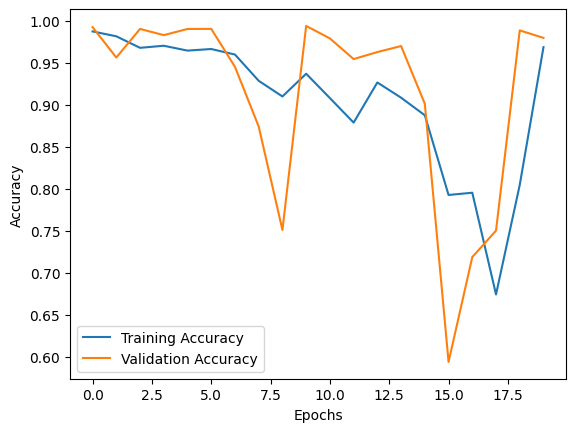

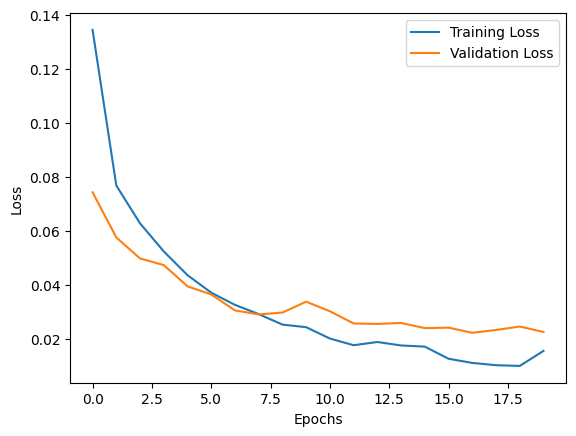

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


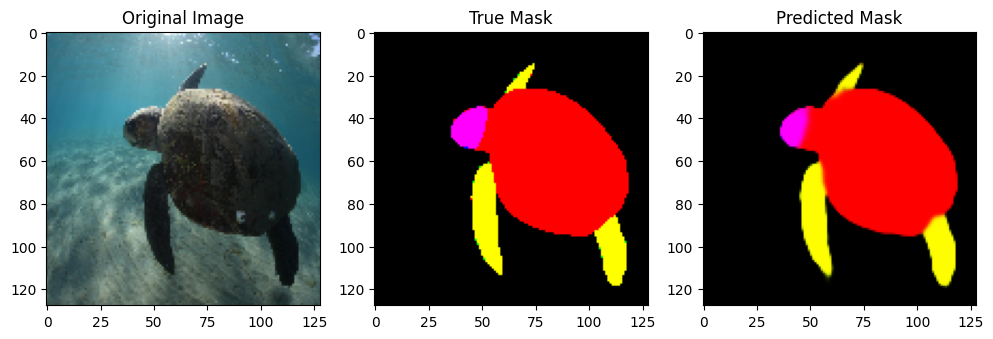

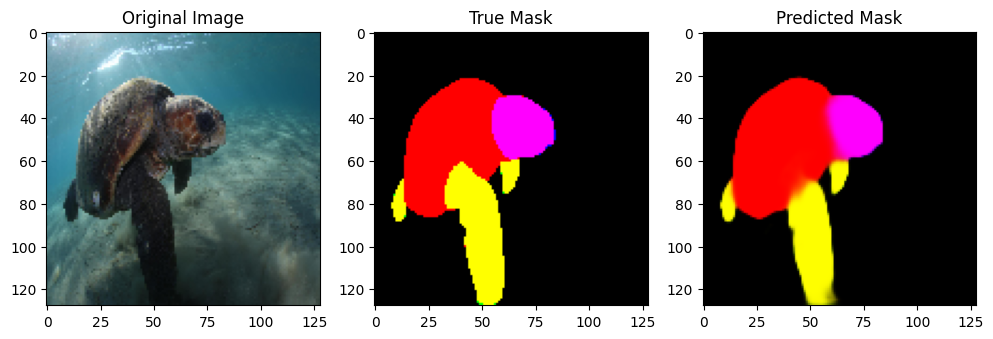

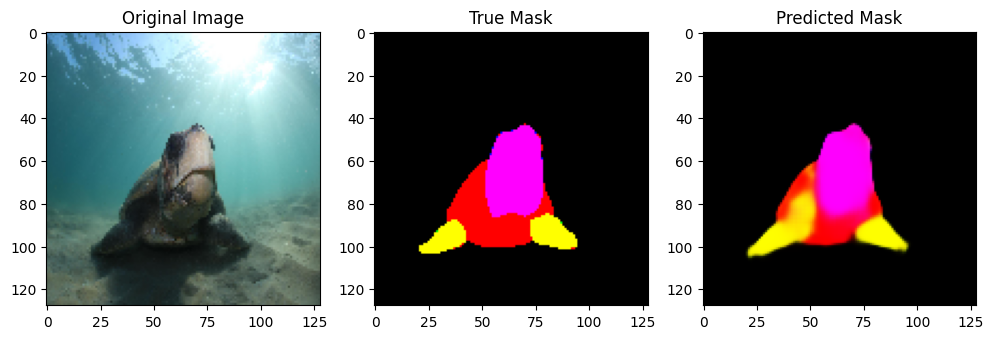

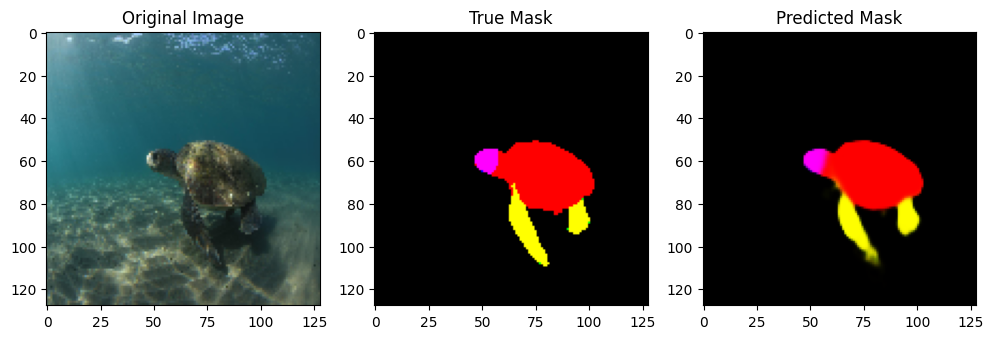

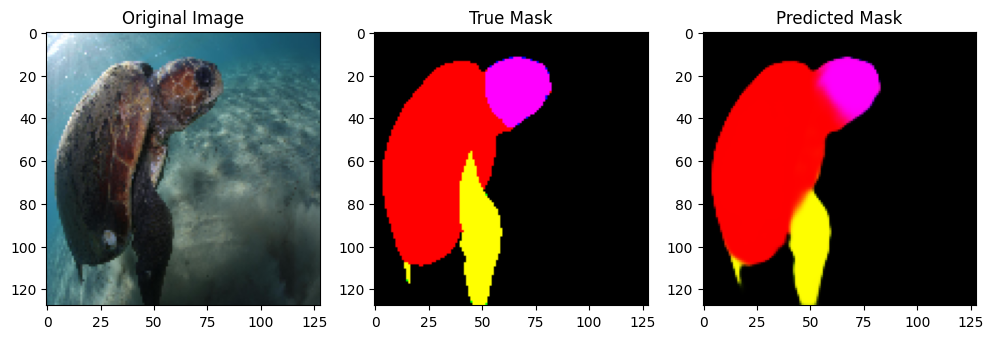

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import h5py


def unet_model(input_shape):
    inputs = layers.Input(input_shape)


    conv1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    conv1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(conv1)
    pool1 = layers.MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(pool1)
    conv2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(conv2)
    pool2 = layers.MaxPooling2D(pool_size=(2, 2))(conv2)

    conv3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(pool2)
    conv3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(conv3)
    pool3 = layers.MaxPooling2D(pool_size=(2, 2))(conv3)

    conv4 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(pool3)
    conv4 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(conv4)
    pool4 = layers.MaxPooling2D(pool_size=(2, 2))(conv4)


    conv5 = layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(pool4)
    conv5 = layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(conv5)


    up6 = layers.Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same')(conv5)
    up6 = layers.concatenate([up6, conv4])
    conv6 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(up6)
    conv6 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(conv6)

    up7 = layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(conv6)
    up7 = layers.concatenate([up7, conv3])
    conv7 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(up7)
    conv7 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(conv7)

    up8 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(conv7)
    up8 = layers.concatenate([up8, conv2])
    conv8 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(up8)
    conv8 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(conv8)

    up9 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(conv8)
    up9 = layers.concatenate([up9, conv1])
    conv9 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(up9)
    conv9 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(conv9)


    outputs = layers.Conv2D(3, (1, 1), activation='sigmoid')(conv9)

    model = models.Model(inputs=[inputs], outputs=[outputs])
    return model


input_shape = (128, 128, X_train.shape[-1])
model = unet_model(input_shape)


optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])


history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=20, batch_size=8)


loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")


plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


def display_predictions(model, X, y, num_samples=5):
    predictions = model.predict(X[:num_samples])
    for i in range(num_samples):
        plt.figure(figsize=(12, 4))


        plt.subplot(1, 3, 1)
        plt.imshow(X[i])
        plt.title('Original Image')


        plt.subplot(1, 3, 2)
        plt.imshow(y[i].squeeze(), cmap='gray')
        plt.title('True Mask')


        plt.subplot(1, 3, 3)
        plt.imshow(predictions[i].squeeze(), cmap='gray')
        plt.title('Predicted Mask')

        plt.show()

display_predictions(model, X_test, y_test)

In [8]:
def calculate_iou(y_true, y_pred):
    y_pred_binary = (y_pred > 0.5).astype(np.float32)
    intersection = np.logical_and(y_true, y_pred_binary)
    union = np.logical_or(y_true, y_pred_binary)
    if np.sum(union) == 0:
        return 0.0
    iou = np.sum(intersection) / np.sum(union)
    return iou


y_pred = model.predict(X_test)


categories = ["carapace", "flippers", "head"]
category_iou = {category: [] for category in categories}

for i in range(len(y_test)):
    for j, category in enumerate(categories):
        y_true_category = y_test[i][..., j]
        y_pred_category = y_pred[i][..., j]
        iou = calculate_iou(y_true_category, y_pred_category)
        category_iou[category].append(iou)


mean_iou = {category: np.mean(iou_list) for category, iou_list in category_iou.items()}


for category, iou in mean_iou.items():
    print(f"Mean IoU (mIoU) for {category}: {iou}")


73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step
Mean IoU (mIoU) for carapace: 0.9135777891822477
Mean IoU (mIoU) for flippers: 0.6685090518324899
Mean IoU (mIoU) for head: 0.6422333283911486
